In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import for precision-recall curve
from sklearn.metrics import precision_recall_curve, precision_score, recall_score
from sklearn.metrics import PrecisionRecallDisplay
import os
import glob


In [2]:
test_predictions = [
    '../data/final_models/Ab17978_predictions.csv',
    '../data/final_models/Kp43816_predictions.csv',
    '../data/final_models/PAO1_predictions.csv',
    '../data/final_models/AbLac4_predictions.csv',
    '../data/final_models/Kp0087_predictions.csv',
    '../data/final_models/Pa0095_predictions.csv'
]

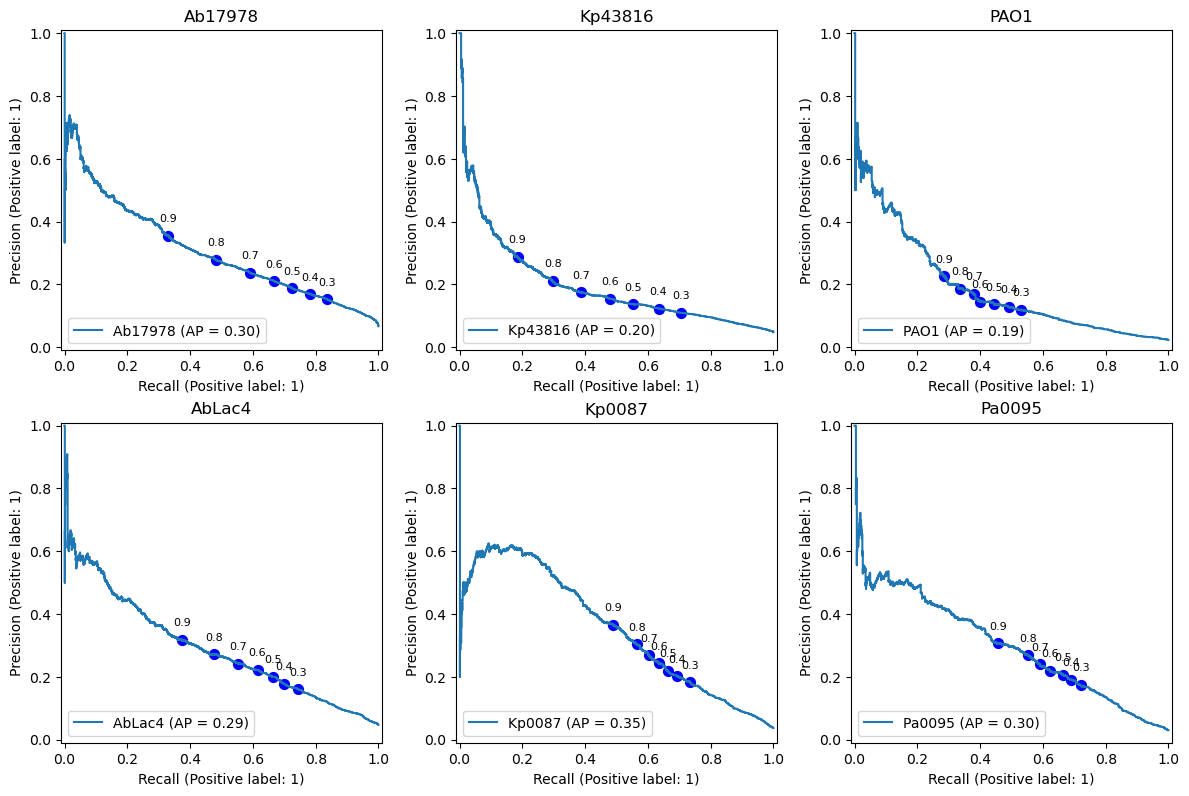

In [3]:
fig, axes = plt.subplots(2,3, figsize=(12, 8))
axes = axes.flatten()
for i, file in enumerate(test_predictions):
    df = pd.read_csv(file)
    basename = os.path.basename(file)
    strain_name = basename.split('_')[0]
    PrecisionRecallDisplay.from_predictions(df['true_labels'], df['predictions_prob'], ax=axes[i], name=strain_name)
    axes[i].set_title(strain_name)
    # displot default threshold.
    threshold_values = [0.3, 0.4, 0.5,0.6, 0.7, 0.8, 0.9]
    for threshold in threshold_values:
        precision = precision_score(df['true_labels'], df['predictions_prob'] > threshold)
        recall = recall_score(df['true_labels'], df['predictions_prob'] > threshold)
        axes[i].scatter(recall, precision, color='blue', label=f'Threshold {threshold}', s=50)
        # Show the threshold value on the plot
        axes[i].annotate(f'{threshold}', (recall, precision), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()